<a href="https://colab.research.google.com/github/marcomunozq-miaad-uacj/Programacion1Semestre/blob/Programacion1Sem/Pr%C3%A1ctica_26_Validaci%C3%B3n%2C_Evaluaci%C3%B3n_y_Selecci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica #26: Validación, Evaluación y Selección
Alumno: Marco Antonio Muñoz Quiroz

**Link Github**



# Carga de Datos

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Semestre1/Programacion/Semana13/TCGA_InfoWithGrade.csv')
df

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,1,1,77.89,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
835,1,0,85.18,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
836,1,1,77.49,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
837,1,0,63.33,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


### 🧬 Descripción completa de las variables del dataset

El dataset **`TCGA_InfoWithGrade.csv`** contiene información clínica y genética de pacientes diagnosticados con **tumores cerebrales (gliomas)**, provenientes del proyecto **The Cancer Genome Atlas (TCGA)**.  
Las variables se dividen en dos grupos principales: **clínicas** y **genéticas**, que en conjunto permiten estudiar cómo las mutaciones moleculares se relacionan con características del paciente y con la agresividad del tumor.

## 🧠 Variables clínicas

#### **1. Grade**
Representa el **grado histológico del tumor**, según la clasificación de la **OMS**, indicando su nivel de malignidad:

- **0:** Tumor de **bajo grado** LGG— crecimiento lento, mejor pronóstico.   
- **1:** **Glioblastoma Multiforme** GBM — muy agresivo, con alta proliferación celular y mal pronóstico.

#### **2. Gender**
Indica el **sexo biológico del paciente**:

- **0:** Masculino.  
- **1:** Femenino.


#### **3. Age_at_diagnosis**
Edad (en años) del paciente al momento del diagnóstico.  
Puede incluir decimales para representar fracciones de año (por ejemplo, *51.3 años ≈ 51 años y 4 meses*).  
Rango típico: **20 a 90 años**.

#### **4. Race**
Clasificación **racial o étnica** del paciente, de acuerdo con la base de datos TCGA:

| Código | Grupo racial / étnico |
|:------:|:-----------------------|
| **0** | White (Blanco) |
| **1** | Black or African American (Afroamericano) |
| **2** | Asian (Asiático) |
| **3** | American Indian or Alaska Native (Nativo americano o de Alaska) |

> 🔹 Las categorías con baja representación (3, 4 y 5) suelen agruparse bajo “Other” para análisis estadísticos.


## 🧪 Variables genéticas (mutaciones)

Cada columna genética indica si el **gen presenta una mutación (1)** o **no la presenta (0)**.  
Estas mutaciones son relevantes para la biología molecular de los gliomas y otros tipos de cáncer.

| Gen | Descripción y función biológica |
|------|--------------------------------|
| **IDH1** | Enzima metabólica. Mutaciones frecuentes en gliomas de bajo grado; se asocian con mejor pronóstico. |
| **TP53** | Gen supresor tumoral clásico. Controla el ciclo celular y apoptosis. Su pérdida aumenta la inestabilidad genómica. |
| **ATRX** | Participa en el mantenimiento de telómeros. Su mutación es característica de gliomas secundarios. |
| **PTEN** | Regula la vía PI3K/AKT, controlando el crecimiento celular. Su pérdida favorece la proliferación tumoral. |
| **EGFR** | Receptor del factor de crecimiento epidérmico. Su amplificación o mutación activa la proliferación celular, típica del glioblastoma. |
| **CIC** | Gen supresor tumoral implicado en oligodendrogliomas; su pérdida afecta la diferenciación celular. |
| **MUC16** | Codifica una mucina transmembranal (CA-125). Asociada a metástasis y evasión inmunológica. |
| **PIK3CA** | Subunidad catalítica de la vía PI3K. Mutaciones activadoras promueven crecimiento y supervivencia celular. |
| **NF1** | Supresor tumoral que regula la vía RAS. Su pérdida genera proliferación descontrolada. |
| **PIK3R1** | Subunidad reguladora de PI3K. Mutaciones alteran la señalización intracelular y favorecen la oncogénesis. |
| **FUBP1** | Regula la expresión de c-Myc; mutaciones promueven proliferación y pérdida del control transcripcional. |
| **RB1** | Supresor del ciclo celular; su pérdida permite replicación sin control. |
| **NOTCH1** | Regula la diferenciación celular; puede actuar como oncogén o supresor según el contexto. |
| **BCOR** | Cofactor represor de BCL6; su mutación altera la represión génica en células progenitoras. |
| **CSMD3** | Gen supresor tumoral. Su deleción se asocia con aumento del crecimiento celular. |
| **SMARCA4** | Parte del complejo SWI/SNF de remodelación de cromatina. Su mutación interfiere con la regulación epigenética. |
| **GRIN2A** | Codifica un receptor de glutamato (NMDA). Alteraciones pueden modificar la señalización neuronal. |
| **IDH2** | Isoforma del gen IDH1. Mutaciones afectan el metabolismo celular (producción de 2-hidroxiglutarato). |
| **FAT4** | Participa en la adhesión y polaridad celular. Actúa como supresor tumoral en varios cánceres. |
| **PDGFRA** | Receptor del factor de crecimiento derivado de plaquetas. Mutaciones activadoras promueven proliferación celular y angiogénesis. |

---

### 📚 Nota
Las variables genéticas y clínicas de este dataset permiten realizar análisis integrativos entre **factores demográficos, moleculares y de pronóstico**.  
Su combinación es útil para el desarrollo de **modelos predictivos de supervivencia, clasificación tumoral** y **predicción de respuesta terapéutica** en pacientes con glioma.



# Análisis exploratorio de datos (EDA)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV, GridSearchCV, RandomizedSearchCV

In [4]:
def header(titulo: str):
    texto = f" {titulo.strip()} "
    linea = "═" * len(texto)
    print(f"\n╔{linea}╗")
    print(f"║{texto}║")
    print(f"╚{linea}╝")

In [5]:
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

header("Shape del DataFrame (filas, columnas)")
filas, columnas = df.shape
print(f"Filas: {filas} | Columnas: {columnas}")

header("Estructura del DataFrame (info)")
df.info()

header("Resumen estadístico")
print(df.describe().T)  # Transpongo


╔═══════════════════════════════════════╗
║ Shape del DataFrame (filas, columnas) ║
╚═══════════════════════════════════════╝
Filas: 839 | Columnas: 24

╔═════════════════════════════════╗
║ Estructura del DataFrame (info) ║
╚═════════════════════════════════╝
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 839 entries, 0 to 838
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Grade             839 non-null    int64  
 1   Gender            839 non-null    int64  
 2   Age_at_diagnosis  839 non-null    float64
 3   Race              839 non-null    int64  
 4   IDH1              839 non-null    int64  
 5   TP53              839 non-null    int64  
 6   ATRX              839 non-null    int64  
 7   PTEN              839 non-null    int64  
 8   EGFR              839 non-null    int64  
 9   CIC               839 non-null    int64  
 10  MUC16             839 non-null    int64  
 11  PIK3CA           


╔═══════════════════════════════════════════════╗
║ Distribución de clases - Resumen (conteo y %) ║
╚═══════════════════════════════════════════════╝
       conteo  porcentaje
Grade                    
0         487       58.05
1         352       41.95

╔═════════════════════════════════════════════════════╗
║ Gráfica de distribución de variable Objetivo: Grade ║
╚═════════════════════════════════════════════════════╝


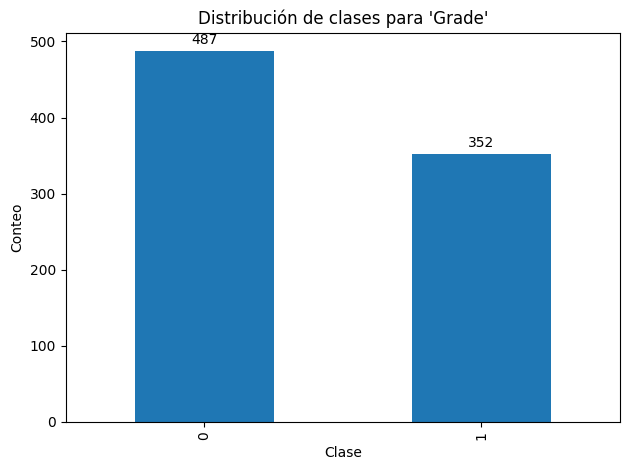

In [6]:
# Defino la columna objetivo
y = df["Grade"]
target_col = "Grade"

# Calculo conteos y porcentajes
conteos = y.value_counts(dropna=False).sort_index()
porcentajes = (y.value_counts(normalize=True, dropna=False) * 100).round(2).sort_index()

# Muestro una tabla combinada (conteo y porcentaje)
header("Distribución de clases - Resumen (conteo y %)")
resumen_clases = (
    pd.DataFrame({"conteo": conteos, "porcentaje": porcentajes})
    .sort_index()  # Ordeno por etiqueta de clase
)
print(resumen_clases)

header("Gráfica de distribución de variable Objetivo: Grade")
ax = resumen_clases["conteo"].plot(kind="bar")
ax.set_xlabel("Clase")
ax.set_ylabel("Conteo")
ax.set_title(f"Distribución de clases para '{target_col}'")
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f"{int(altura)}", (p.get_x() + p.get_width() / 2, altura),
                ha="center", va="bottom", xytext=(0, 3), textcoords="offset points")
plt.tight_layout()
plt.show()


╔═══════════════════════════════════════════════════════════════╗
║ Histogramas — mosaico de columnas numericas (borde y espacio) ║
╚═══════════════════════════════════════════════════════════════╝
Columnas numericas detectadas: 24


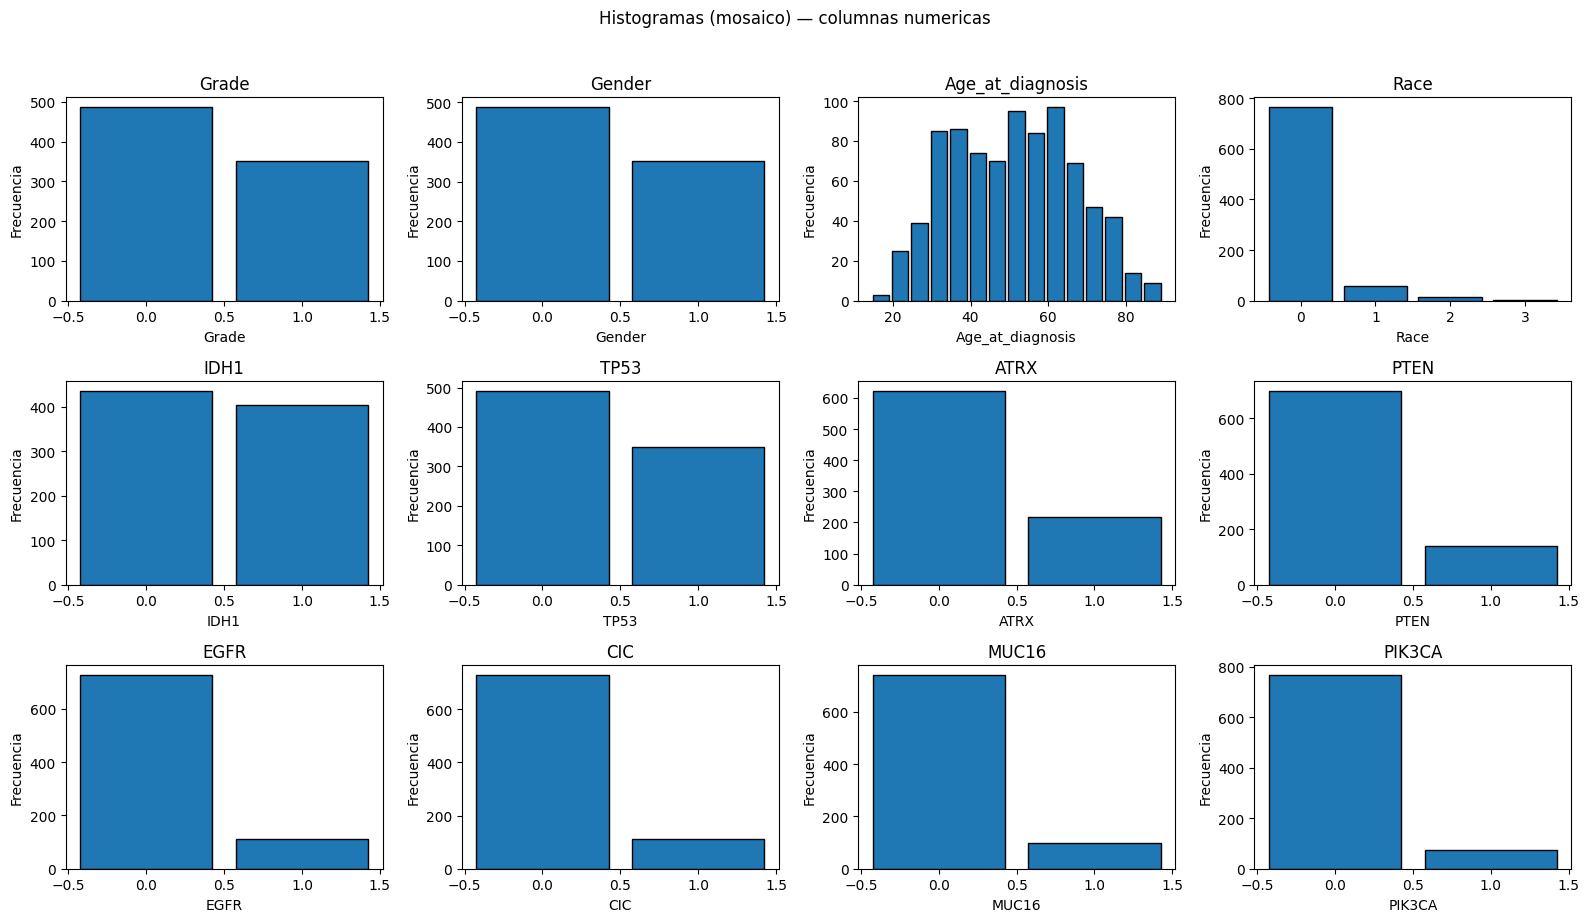

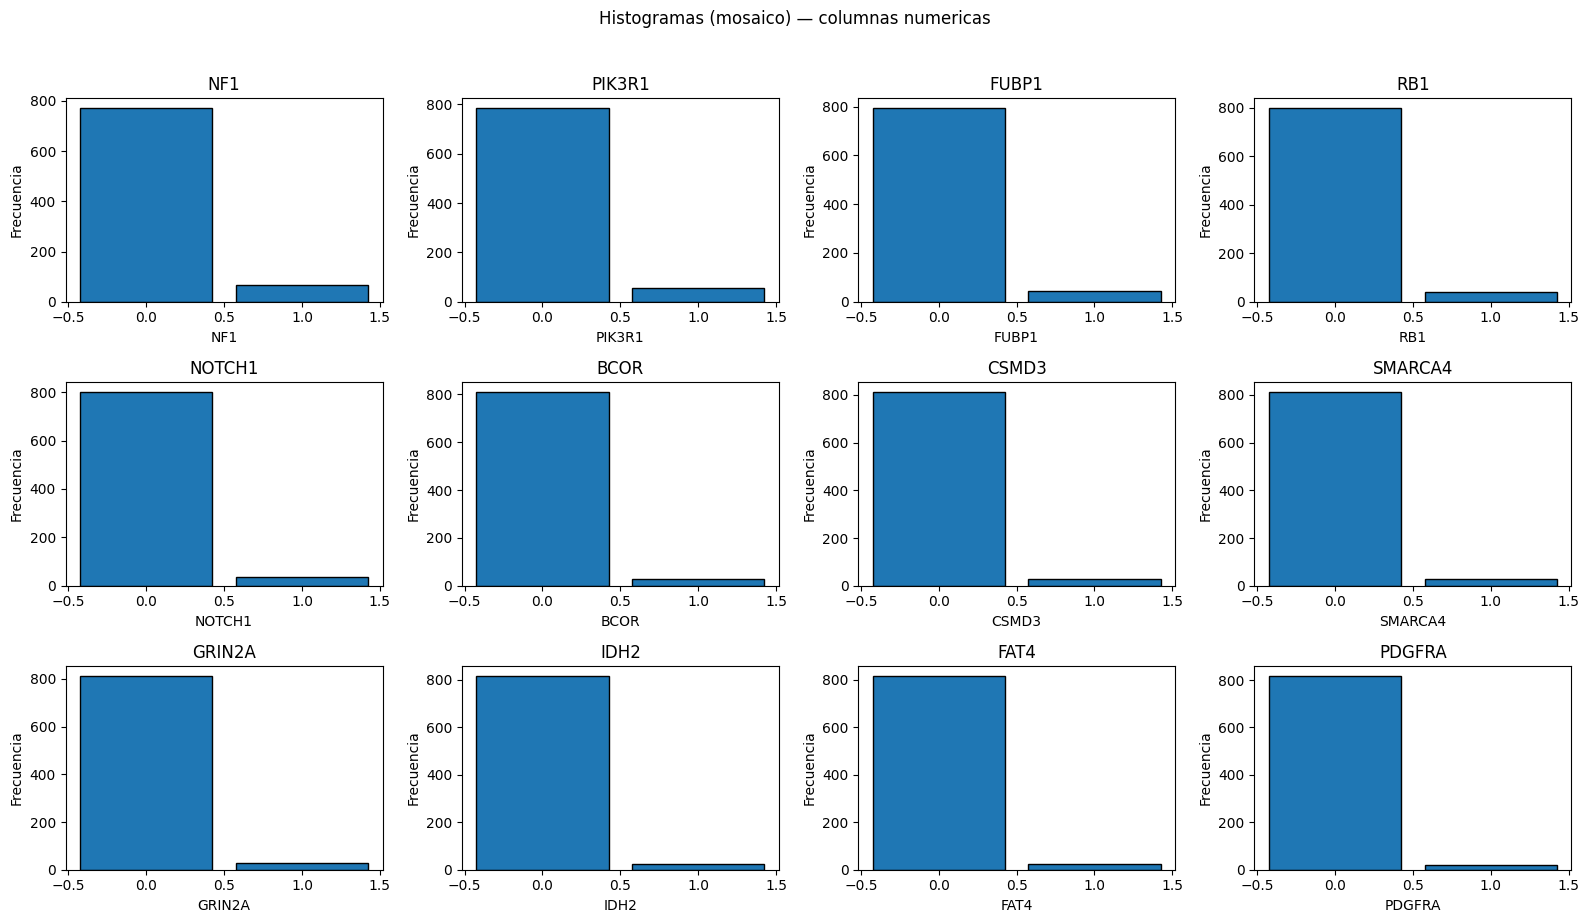

In [7]:
header("Histogramas — mosaico de columnas numericas (borde y espacio)")

# columnas numericas
cols_numericas = df.select_dtypes(include=["number"]).columns.tolist()
num_cols = len(cols_numericas)
print(f"Columnas numericas detectadas: {num_cols}")

# tamano del mosaico
N_FILAS = 3
N_COLS  = 4
POR_PAG = N_FILAS * N_COLS

# decide bins discretos si hay pocos valores enteros
def bins_discretos(serie):
    vals = serie.dropna().unique()
    if len(vals) <= 10 and np.all(np.equal(np.mod(vals, 1), 0)):
        vmin = int(np.min(vals))
        vmax = int(np.max(vals))
        return np.arange(vmin - 0.5, vmax + 1.5, 1)  # centra en enteros
    return "auto"

# recorre en paginas para no saturar una sola figura
for i in range(0, num_cols, POR_PAG):
    grupo = cols_numericas[i : i + POR_PAG]
    n_actual = len(grupo)

    fig, axes = plt.subplots(N_FILAS, N_COLS, figsize=(N_COLS * 4, N_FILAS * 3))
    axes = np.atleast_2d(axes)

    # llena el mosaico
    for idx, col in enumerate(grupo):
        r = idx // N_COLS
        c = idx % N_COLS
        ax = axes[r, c]

        serie = df[col].dropna()
        b = bins_discretos(serie)
        ax.hist(
            serie,
            bins=b,
            edgecolor="black",   # contorno negro
            linewidth=1.0,       # grosor del borde
            rwidth=0.85          # deja espacio entre barras
        )
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("Frecuencia")

    # apaga celdas vacias si sobran
    for k in range(n_actual, POR_PAG):
        r = k // N_COLS
        c = k % N_COLS
        axes[r, c].axis("off")

    plt.suptitle("Histogramas (mosaico) — columnas numericas", y=1.02)
    plt.tight_layout()
    plt.show()


╔═══════════════════════════════════════╗
║ Distribuciones por clase (box/violin) ║
╚═══════════════════════════════════════╝
Columnas a graficar: 23


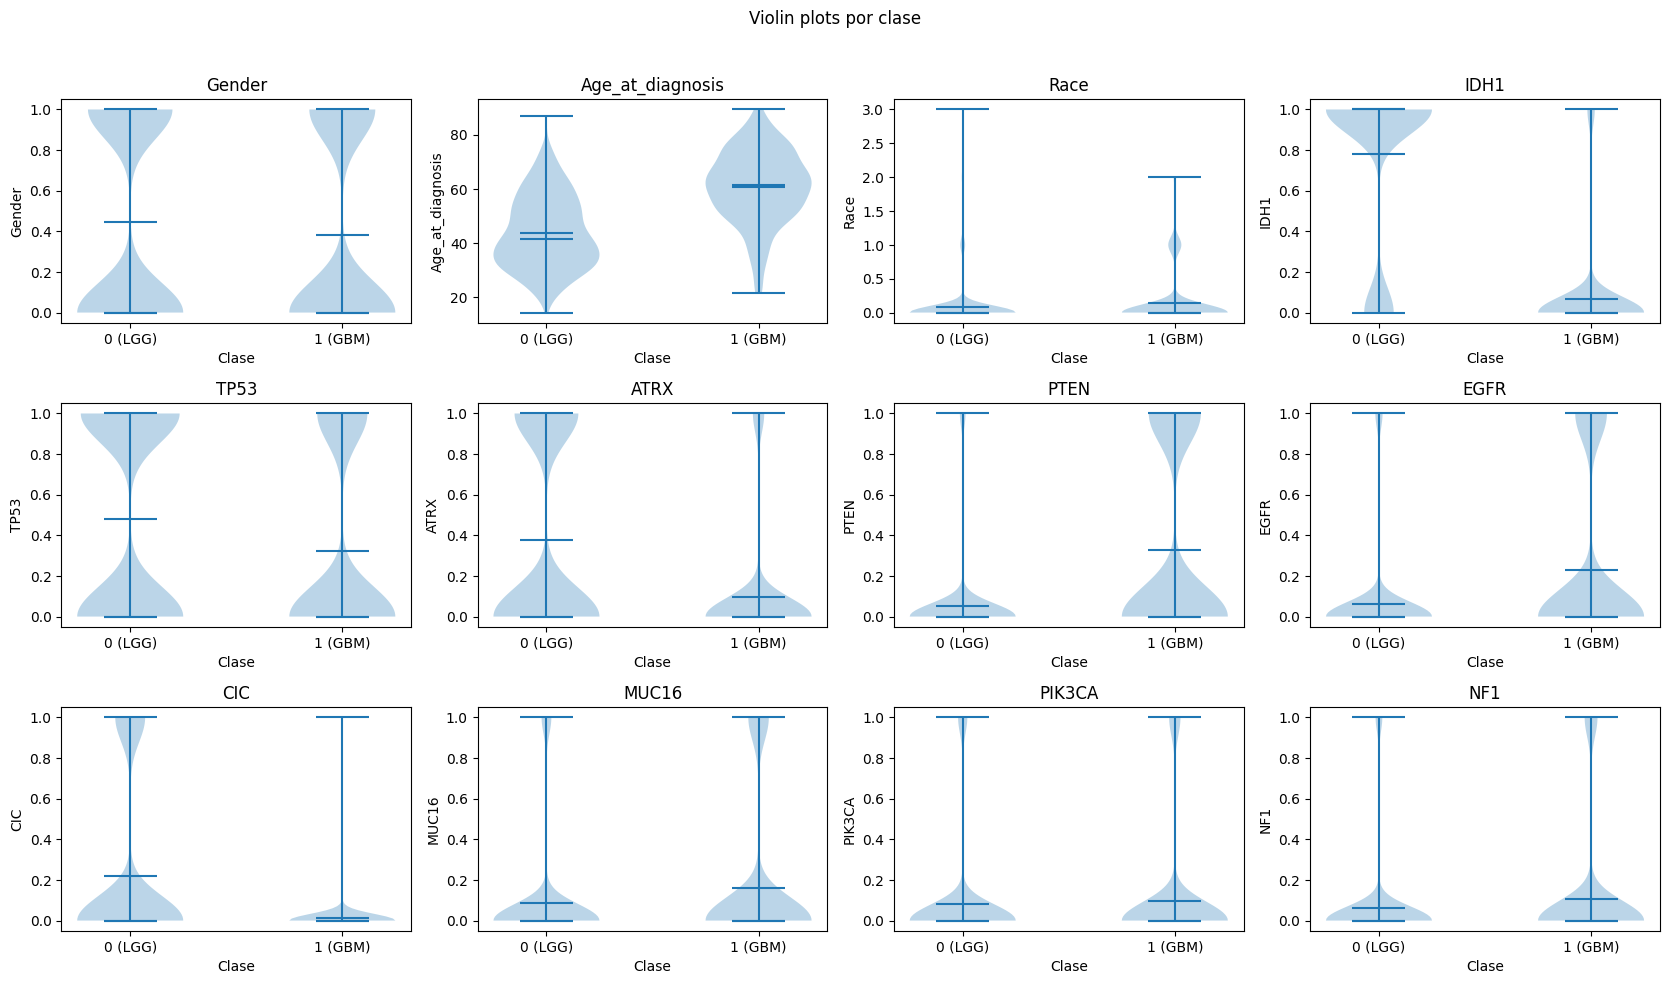

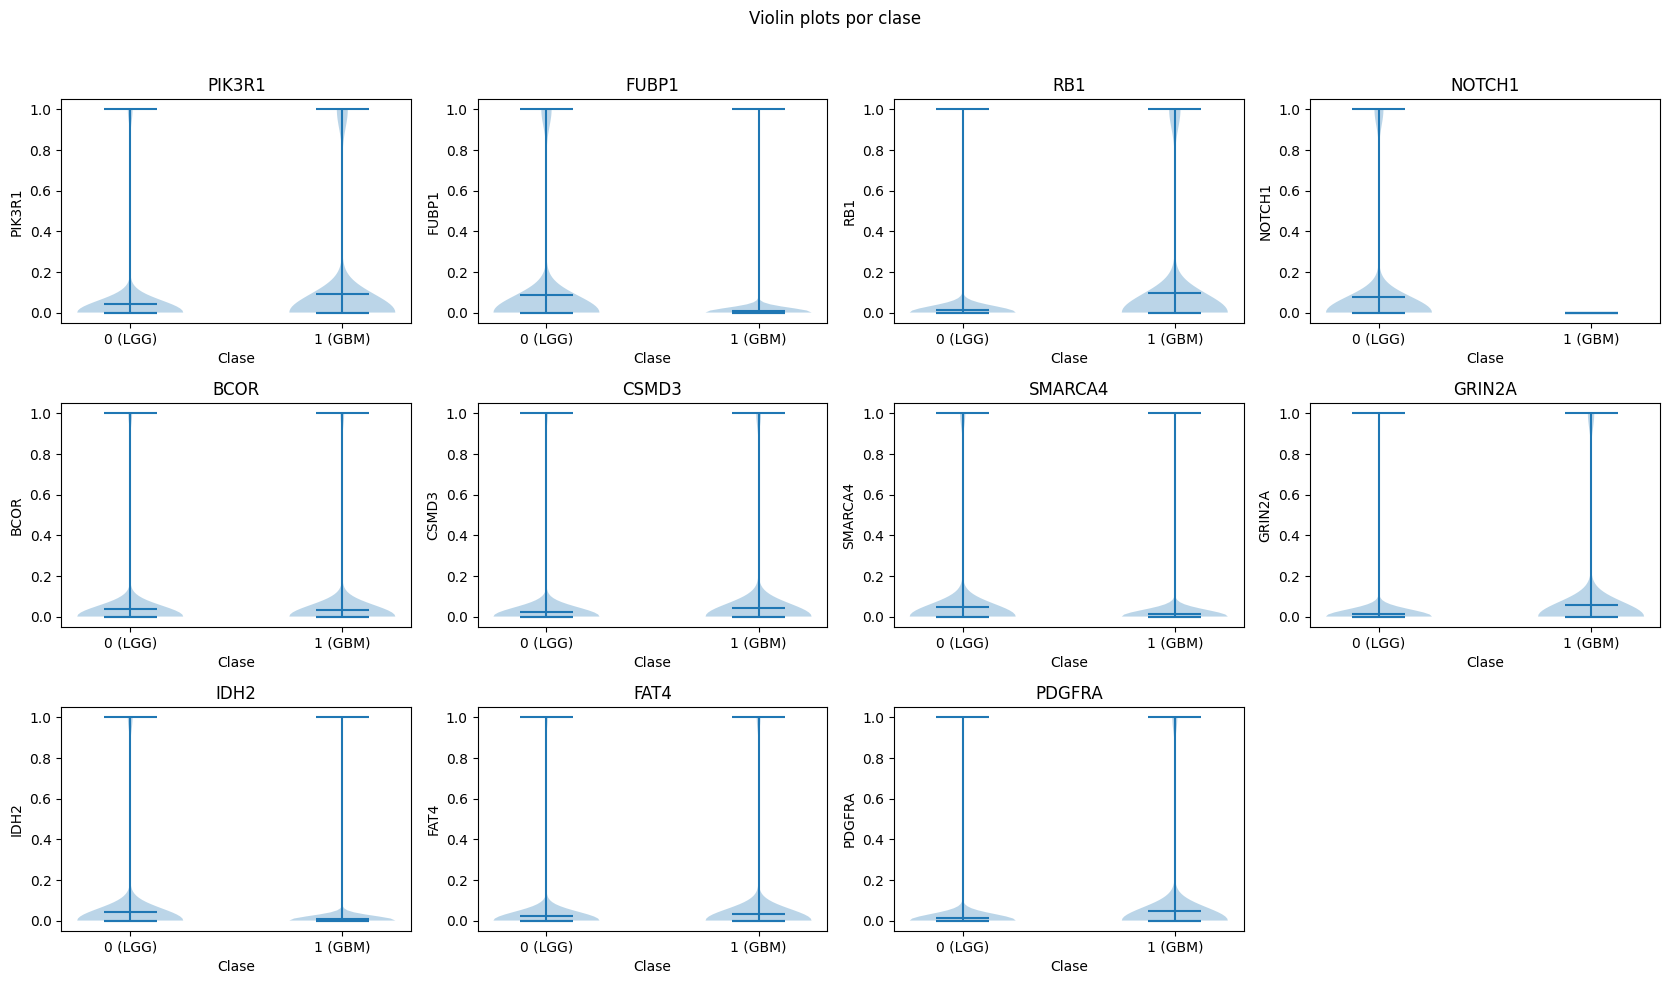

In [8]:
header("Distribuciones por clase (box/violin)")

# config basica
TARGET = "Grade"         # columna objetivo
KIND   = "violin"           # "box" o "violin"
N_FILAS = 3              # filas del mosaico
N_COLS  = 4              # columnas del mosaico
POR_PAG = N_FILAS * N_COLS

# si quiero saltar columnas con muy pocos valores unicos (p. ej. binarias)
SKIP_LOW_CARD = False # con False se añaden las columnas de valores binarios
LOW_CARD_THRESHOLD = 3   # salta si nunique <= 3

# tomo columnas numericas y quito el target
cols_num = df.select_dtypes(include=["number"]).columns.tolist()
cols_num = [c for c in cols_num if c != TARGET]

# filtro columnas de baja cardinalidad si aplica
if SKIP_LOW_CARD:
    cols_num = [c for c in cols_num if df[c].nunique(dropna=True) > LOW_CARD_THRESHOLD]

print(f"Columnas a graficar: {len(cols_num)}")

# preparo indices de clases presentes
clases = sorted(df[TARGET].dropna().unique().tolist())
# si esperas 0 y 1, pero por seguridad:
if len(clases) < 2:
    print("Solo hay una clase en la columna objetivo, no puedo comparar.")
else:
    # recorro en paginas para no saturar
    for i in range(0, len(cols_num), POR_PAG):
        grupo = cols_num[i : i + POR_PAG]
        n_actual = len(grupo)

        fig, axes = plt.subplots(N_FILAS, N_COLS, figsize=(N_COLS * 4.2, N_FILAS * 3.2))
        axes = np.atleast_2d(axes)

        for idx, col in enumerate(grupo):
            r = idx // N_COLS
            c = idx % N_COLS
            ax = axes[r, c]

            # preparo datos por clase
            datos = [df.loc[df[TARGET] == cl, col].dropna().values for cl in clases]

            # si todos vacios, salto
            if all(len(x) == 0 for x in datos):
                ax.set_title(f"{col} (sin datos)")
                ax.axis("off")
                continue

            # grafico segun KIND
            if KIND.lower() == "violin":
                parts = ax.violinplot(
                    datos,
                    showmeans=True,
                    showmedians=True
                )
                # no defino colores, matplotlib usa por defecto
            else:
                bp = ax.boxplot(
                    datos,
                    showmeans=True
                )

            ax.set_title(col)
            ax.set_xlabel("Clase")
            ax.set_ylabel(col)
            # etiquetas de 1..k a nombres reales de clases
            ax.set_xticks(range(1, len(clases) + 1))
            # mapea 0/1 a textos mas claros
            etiquetas = []
            for cl in clases:
                if cl == 0:
                    etiquetas.append("0 (LGG)")
                elif cl == 1:
                    etiquetas.append("1 (GBM)")
                else:
                    etiquetas.append(str(cl))
            ax.set_xticklabels(etiquetas, rotation=0)

        # apago ejes vacios sobrantes
        for k in range(n_actual, POR_PAG):
            r = k // N_COLS
            c = k % N_COLS
            axes[r, c].axis("off")

        titulo = "Violin plots por clase" if KIND.lower() == "violin" else "Boxplots por clase"
        plt.suptitle(titulo, y=1.02)
        plt.tight_layout()
        plt.show()



╔══════════════════════════════════════════╗
║ Mapa de calor de correlaciones (Pearson) ║
╚══════════════════════════════════════════╝


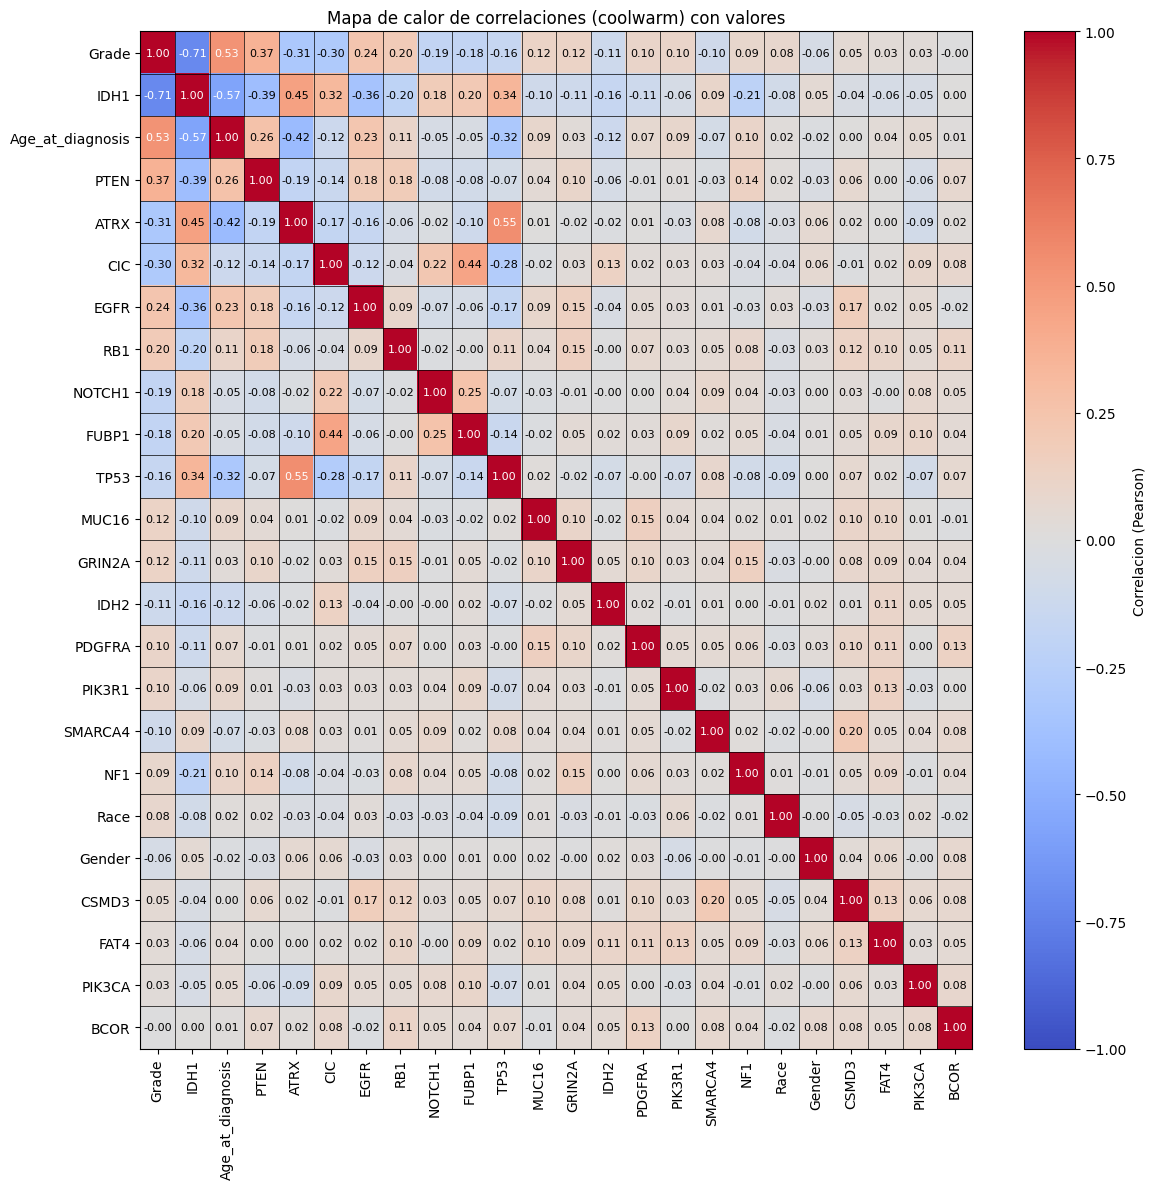

In [9]:
# mapa de calor con valores en cada recuadro
# requiere: df, header(), numpy como np y matplotlib.pyplot como plt

header("Mapa de calor de correlaciones (Pearson)")

# columnas numericas
cols_num = df.select_dtypes(include=["number"]).columns.tolist()

# quito columnas constantes
cols_validas = [c for c in cols_num if df[c].nunique(dropna=True) > 1]
mat = df[cols_validas].corr(method="pearson")

# ordeno por correlacion con Grade si existe
if "Grade" in mat.columns:
    orden = mat["Grade"].abs().sort_values(ascending=False).index
    mat = mat.loc[orden, orden]

# tamanio de figura segun n
n = mat.shape[0]
fig_w = min(max(n * 0.5, 6), 30)
fig_h = min(max(n * 0.5, 6), 30)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# imagen con paleta coolwarm
img = ax.imshow(mat.values, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")

# ticks y etiquetas
ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(mat.columns, rotation=90)
ax.set_yticklabels(mat.index)

# agrego rejilla para ver los recuadros
ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color="black", linestyle="-", linewidth=0.5)
ax.tick_params(which="minor", length=0)

# colorbar
cbar = plt.colorbar(img, ax=ax)
cbar.set_label("Correlacion (Pearson)")

# decido color del texto segun el fondo para que se lea bien
def color_texto(v):
    # si el valor es alto en magnitud, el fondo sera fuerte: uso blanco
    return "white" if abs(v) >= 0.5 else "black"

# tamano de fuente dinamico para no saturar
fontsize = 9 if n <= 20 else max(4, 12 - n // 5)

# escribo cada valor dentro de su recuadro
for i in range(n):
    for j in range(n):
        val = mat.values[i, j]
        ax.text(
            j, i, f"{val:.2f}",
            ha="center", va="center",
            color=color_texto(val),
            fontsize=fontsize
        )

plt.title("Mapa de calor de correlaciones (coolwarm) con valores")
plt.tight_layout()
plt.show()


**¿Existen clases desbalanceadas?**

La variable objetivo Grade no esta completamente balanceada, 58% vs 42%.
Creo que simplemente usare estratificacion al momento de dividir los datos en test & train para mantener la misma proporcion de los datos.

**¿Qué atributos parecen más informativos?**

Las variables* Age_at_diagnosis* e *IDH1* influyen mucho en el modelo porque están directamente relacionadas con el tipo de glioma. En general, los pacientes con GBM (1) suelen ser mayores de edad, mientras que los de LGG (0) son más jóvenes, por eso la edad ayuda al modelo a separar las clases fácilmente. Además, la mutación en el gen IDH1 es muy común en los tumores de bajo grado (LGG = 0) y casi ausente en GBM (1), lo que la convierte en un indicador genético muy fuerte para distinguir entre ambos tipos de cáncer.

# Gráfica de Errores en Entrenamiento y Prueba

* En este ejercicio vas a entrenar un árbol de decisión con diferentes
profundidas.

* Asimismo, en gráfica mostrarás las exactitudes en entrenamiento y test, usando un stratified k-fold cross-validation con K= 10

* Los valores de las profundides a evaluar son 2, 5, 10, 15, 20, 25, 30 y None

* Deberás usar StratifiedKFold con 10 particiones, y un valor aleaotorio de 3

* Entrenarás y evaluarás un árbol de decisión con estos distintos valores de profundidades

* Usa cross_val_score para entrenar los modelos, usando como métrica de evaluación en scoring ="f1_macro",y el StratifiedKFold, con un valor aleatorio = 7

* Muestra una fráfica para los distintos resultados  cuando se usa F1 Macro

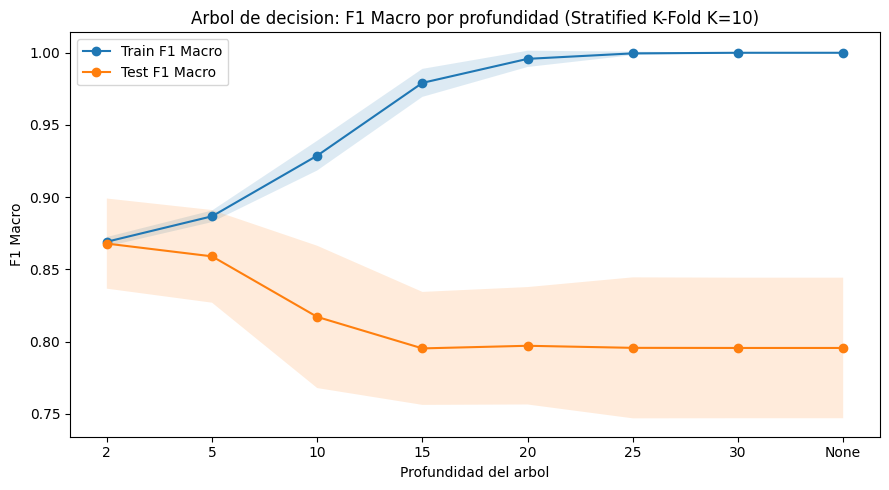

  depth  train_f1_mean  train_f1_std  test_f1_mean  test_f1_std
0     2         0.8691        0.0033        0.8678       0.0312
1     5         0.8867        0.0040        0.8590       0.0321
2    10         0.9288        0.0103        0.8170       0.0493
3    15         0.9792        0.0097        0.7952       0.0391
4    20         0.9958        0.0056        0.7971       0.0407
5    25         0.9996        0.0012        0.7956       0.0488
6    30         1.0000        0.0000        0.7955       0.0487
7  None         1.0000        0.0000        0.7955       0.0487


In [10]:
# Entreno arboles de decision con distintas profundidades y mido F1 Macro
# Uso validacion cruzada estratificada (K=10) para tener una evaluacion mas estable
# Grafico el F1 Macro promedio en train y en test para cada profundidad

# preparo los datos
# y es la columna objetivo (Grade). X son las variables numericas excepto Grade.
target_col = "Grade"
X = df.drop(columns=[target_col]).select_dtypes(include=["number"]).copy()
y = df[target_col].values

# profundidades a probar
# None significa sin limite de profundidad (el arbol puede crecer todo lo que quiera)
depths = [2, 5, 10, 15, 20, 25, 30, None]

# configuracion de la validacion cruzada
# StratifiedKFold mantiene la proporcion de clases en cada particion.
# K=10 partes. random_state=7 para reproducibilidad. shuffle=True para mezclar antes de partir.
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=7)

# listas para guardar resultados
train_means = []  # F1 Macro promedio en train por profundidad
test_means  = []  # F1 Macro promedio en test por profundidad
train_stds  = []  # desviacion estandar en train
test_stds   = []  # desviacion estandar en test

# ciclo principal: entreno y evalua cada profundidad
for d in depths:
    # creo el arbol con la profundidad actual
    # random_state=3 fija el componente aleatorio del modelo
    clf = DecisionTreeClassifier(max_depth=d, random_state=3)

    # uso cross_validate para obtener puntajes en train y en test
    # scoring="f1_macro" mide F1 promediado por clase (bueno cuando hay desbalance)
    scores = cross_validate(
        clf,
        X, y,
        cv=cv,
        scoring="f1_macro",
        return_train_score=True
    )

    # guardo promedios y desviaciones
    train_means.append(scores["train_score"].mean())
    test_means.append(scores["test_score"].mean())
    train_stds.append(scores["train_score"].std())
    test_stds.append(scores["test_score"].std())

# preparo el eje x de la grafica
x_labels = [("None" if d is None else str(d)) for d in depths]
x = np.arange(len(depths))

# grafico resultados
# una linea para train y otra para test, asi puedo comparar sobreajuste vs generalizacion
plt.figure(figsize=(9, 5))

# linea de train
plt.plot(x, train_means, marker="o", label="Train F1 Macro")
# banda de desviacion para train (opcional, da idea de variabilidad entre folds)
plt.fill_between(
    x,
    np.array(train_means) - np.array(train_stds),
    np.array(train_means) + np.array(train_stds),
    alpha=0.15
)

# linea de test
plt.plot(x, test_means, marker="o", label="Test F1 Macro")
# banda de desviacion para test
plt.fill_between(
    x,
    np.array(test_means) - np.array(test_stds),
    np.array(test_means) + np.array(test_stds),
    alpha=0.15
)

# etiquetas y formato
plt.xticks(x, x_labels)
plt.xlabel("Profundidad del arbol")
plt.ylabel("F1 Macro")
plt.title("Arbol de decision: F1 Macro por profundidad (Stratified K-Fold K=10)")
plt.legend()
plt.tight_layout()
plt.show()

# tabla resumen
# dejo una tabla con los promedios y desviaciones para inspeccion rapida
res = pd.DataFrame({
    "depth": x_labels,
    "train_f1_mean": np.round(train_means, 4),
    "train_f1_std":  np.round(train_stds, 4),
    "test_f1_mean":  np.round(test_means, 4),
    "test_f1_std":   np.round(test_stds, 4),
})
print(res)


# Optimización de hiperparámetros con RandomizedSearchCV

* Define el espacio de búsqueda aleatorio para los siguientes hiperpárametros:Usa el árbol de decisión
  * Criterion = gini ,entropy
  * max_depth: de 5 a 50 con incrementos de 1
  * min_samples_split: de 2 a 20 con incrementos de 1
* StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
* n_iter = 5 (combinaciones aleatorias a buscar)
* n_jobs = -1 para acelerar cómputo
* Métrica de evaluación: f1 Macro
* Imprime los mejores hiperparámetros encontrados
* Imprime el best_score

In [11]:
# RandomizedSearchCV para tunear un arbol de decision
# uso todo el dataset y hago validacion cruzada estratificada (K=10)
# mido con F1 macro y busco 5 combinaciones al azar

# preparo X e y
# uso solo columnas numericas y quito la etiqueta Grade
target_col = "Grade"
X = df.drop(columns=[target_col]).select_dtypes(include=["number"]).copy()
y = df[target_col].values

# defino el espacio de busqueda
# criterion: gini o entropy
# max_depth: de 5 a 50
# min_samples_split: de 2 a 20
param_dist = {
    "criterion": ["gini", "entropy"],
    "max_depth": list(range(5, 51, 1)),
    "min_samples_split": list(range(2, 21, 1)),
}

# defino el esquema de CV estratificado (K=10)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=7)

# modelo base con semilla fija
base_clf = DecisionTreeClassifier(random_state=3)

# configuro la busqueda aleatoria
search = RandomizedSearchCV(
    estimator=base_clf,
    param_distributions=param_dist,
    n_iter=5,                 # numero de combinaciones al azar
    scoring="f1_macro",       # metrica pedida
    n_jobs=-1,                # usa todos los nucleos disponibles
    cv=cv,                    # StratifiedKFold de 10
    random_state=7,           # semilla de la busqueda
    refit=True,               # reentrena con los mejores params al final
    return_train_score=False, # no necesito score de train aqui
    verbose=1
)

# ejecuto la busqueda
header("RandomizedSearchCV: ejecutando busqueda")
search.fit(X, y)

# imprimo los mejores hiperparametros y el mejor score
header("Mejores hiperparametros encontrados")
print(search.best_params_)

header("Mejor puntaje (best_score) - F1 Macro (promedio CV)")
print(f"{search.best_score_:.4f}")

# (opcional) muestro un top 10 de resultados ordenados por mean_test_score
# esto ayuda a ver otras combinaciones que salieron bien
header("Top 10 resultados de la busqueda (mean_test_score)")
cvres = pd.DataFrame(search.cv_results_)
cols_show = ["mean_test_score", "std_test_score", "param_criterion", "param_max_depth", "param_min_samples_split"]
print(cvres.sort_values("mean_test_score", ascending=False)[cols_show].head(10))



╔═════════════════════════════════════════╗
║ RandomizedSearchCV: ejecutando busqueda ║
╚═════════════════════════════════════════╝
Fitting 10 folds for each of 5 candidates, totalling 50 fits

╔═════════════════════════════════════╗
║ Mejores hiperparametros encontrados ║
╚═════════════════════════════════════╝
{'min_samples_split': 9, 'max_depth': 43, 'criterion': 'entropy'}

╔═════════════════════════════════════════════════════╗
║ Mejor puntaje (best_score) - F1 Macro (promedio CV) ║
╚═════════════════════════════════════════════════════╝
0.8189

╔════════════════════════════════════════════════════╗
║ Top 10 resultados de la busqueda (mean_test_score) ║
╚════════════════════════════════════════════════════╝
   mean_test_score  std_test_score param_criterion  param_max_depth  param_min_samples_split
4         0.818876        0.029655         entropy               43                        9
3         0.818402        0.049171            gini               31                       1

# Optimización de hiperparámetros con GridSearchCV

* Define el espacio de búsqueda  para los siguientes hiperpárametros:Usa el árbol de decisión
  * Criterion = gini ,entropy
  * max_depth: de 5 a 50 con incrementos de 1
  * min_samples_split: de 2 a 20 con incrementos de 1
* StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
* Métrica de evaluación: f1 Macro
* n_jobs = -1 para acelerar cómputo
* Imprime los mejores hiperparámetros encontrados
* Imprime el best_score

In [12]:
# preparo X e y
# y es Grade
# X es el resto excepto Grade
target_col = "Grade"
X = df.drop(columns=[target_col]).select_dtypes(include=["number"]).copy()
y = df[target_col].values

# espacio de busqueda
# criterion: gini o entropy
# max_depth: 5 a 50
# min_samples_split: 2 a 20
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": list(range(5, 51, 1)),
    "min_samples_split": list(range(2, 21, 1)),
}

# validacion cruzada
# estratificado con 10 particiones
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=7)

# modelo base
tree_clf = DecisionTreeClassifier(random_state=3)

# configuracion de grid search
# scoring f1 macro
# n_jobs -1 para usar todos los nucleos
search = GridSearchCV(
    estimator=tree_clf,
    param_grid=param_grid,
    scoring="f1_macro",
    n_jobs=-1,
    cv=cv,
    refit=True,
    verbose=1,
    return_train_score=False
)

# ejecuto la busqueda
header("GridSearchCV: buscando mejores hiperparametros")
search.fit(X, y)

# mejores hiperparametros
header("Mejores hiperparametros")
print(search.best_params_)

# mejor score promedio en cv
header("Mejor score (F1 Macro, promedio CV)")
print(f"{search.best_score_:.4f}")

# tabla top para ver combinaciones cercanas
header("Top resultados por mean_test_score")
resultados = pd.DataFrame(search.cv_results_)
cols_show = [
    "mean_test_score",
    "std_test_score",
    "param_criterion",
    "param_max_depth",
    "param_min_samples_split"
]
print(
    resultados.sort_values("mean_test_score", ascending=False)[cols_show].head(10)
)



╔════════════════════════════════════════════════╗
║ GridSearchCV: buscando mejores hiperparametros ║
╚════════════════════════════════════════════════╝
Fitting 10 folds for each of 1748 candidates, totalling 17480 fits

╔═════════════════════════╗
║ Mejores hiperparametros ║
╚═════════════════════════╝
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 13}

╔═════════════════════════════════════╗
║ Mejor score (F1 Macro, promedio CV) ║
╚═════════════════════════════════════╝
0.8641

╔════════════════════════════════════╗
║ Top resultados por mean_test_score ║
╚════════════════════════════════════╝
     mean_test_score  std_test_score param_criterion  param_max_depth  param_min_samples_split
885         0.864057        0.029655         entropy                5                       13
887         0.864057        0.029655         entropy                5                       15
886         0.864057        0.029655         entropy                5                       14
89

# Optimización de hiperparámetros con RandomizedSearchCV: Accuracy

* Define el espacio de búsqueda aleatorio para los siguientes hiperpárametros:Usa el árbol de decisión
  * Criterion = gini ,entropy
  * max_depth: de 5 a 50 con incrementos de 1
  * min_samples_split: de 2 a 20 con incrementos de 1
* StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
* n_iter = 5 (combinaciones aleatorias a buscar)
* n_jobs = -1 para acelerar cómputo
* Métrica de evaluación: accuracy
* Imprime los mejores hiperparámetros encontrados
* Imprime el best_score

In [13]:
# preparo X e y
# y es Grade
# X son columnas numericas excepto Grade
target_col = "Grade"
X = df.drop(columns=[target_col]).select_dtypes(include=["number"]).copy()
y = df[target_col].values

# espacio de busqueda aleatorio
# criterion gini o entropy
# max_depth 5 a 50
# min_samples_split 2 a 20
param_dist = {
    "criterion": ["gini", "entropy"],
    "max_depth": list(range(5, 51, 1)),
    "min_samples_split": list(range(2, 21, 1)),
}

# validacion cruzada
# estratificado con 10 particiones
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=7)

# modelo base
tree_clf = DecisionTreeClassifier(random_state=3)

# config de randomized search
# scoring accuracy
# n_jobs -1 usa todos los nucleos
search = RandomizedSearchCV(
    estimator=tree_clf,
    param_distributions=param_dist,
    n_iter=5,
    scoring="accuracy",
    n_jobs=-1,
    cv=cv,
    random_state=7,
    refit=True,
    verbose=1,
    return_train_score=False
)

# ejecuto la busqueda
header("RandomizedSearchCV con accuracy")
search.fit(X, y)

# mejores hiperparametros
header("Mejores hiperparametros")
print(search.best_params_)

# mejor score promedio en cv
header("Mejor score (accuracy, promedio CV)")
print(f"{search.best_score_:.4f}")

# tabla top para ver combinaciones cercanas
header("Top resultados por mean_test_score (accuracy)")
resultados = pd.DataFrame(search.cv_results_)
cols_show = [
    "mean_test_score",
    "std_test_score",
    "param_criterion",
    "param_max_depth",
    "param_min_samples_split"
]
print(
    resultados.sort_values("mean_test_score", ascending=False)[cols_show].head(10)
)



╔═════════════════════════════════╗
║ RandomizedSearchCV con accuracy ║
╚═════════════════════════════════╝
Fitting 10 folds for each of 5 candidates, totalling 50 fits

╔═════════════════════════╗
║ Mejores hiperparametros ║
╚═════════════════════════╝
{'min_samples_split': 10, 'max_depth': 31, 'criterion': 'gini'}

╔═════════════════════════════════════╗
║ Mejor score (accuracy, promedio CV) ║
╚═════════════════════════════════════╝
0.8248

╔═══════════════════════════════════════════════╗
║ Top resultados por mean_test_score (accuracy) ║
╚═══════════════════════════════════════════════╝
   mean_test_score  std_test_score param_criterion  param_max_depth  param_min_samples_split
3         0.824799        0.046396            gini               31                       10
4         0.824771        0.028331         entropy               43                        9
2         0.818818        0.041572            gini               33                        7
0         0.817642        0.03

# Actividad de reflexión y *análisis*

**¿Cuál método encontró mejores hiperparámetros?**

Después de comparar los tres resultados, se puede ver que el método que encontró los mejores hiperparámetros fue el GridSearchCV con la métrica F1 Macro. Este método obtuvo un puntaje promedio (best_score) de 0.8641, con los hiperparámetros criterion='entropy', max_depth=5 y min_samples_split=13. En cambio, el RandomizedSearchCV con F1 Macro alcanzó 0.8189, y el RandomizedSearchCV con accuracy llegó a 0.8248. Por lo tanto, el GridSearchCV fue el que logró el mejor desempeño global, encontrando una combinación más óptima y, además, un modelo más simple (menor profundidad) que probablemente generaliza mejor.

**¿Cuál fue más costoso computacionalmente?**

El método más costoso computacionalmente fue GridSearchCV, ya que prueba todas las combinaciones posibles de hiperparámetros dentro del espacio definido.
GridSearchCV evaluó 1,748 combinaciones, mientras que RandomizedSearchCV solo probó 5 combinaciones al azar.

Esto significa que GridSearchCV realizó muchos más entrenamientos (17,480 en total, por los 10 folds del K-Fold), lo que explica por qué tarda más tiempo y consume más recursos.

**¿Los resultados en f1_macro set fueron distintos en ambos métodos de optimización? ¿Por qué?**

Sí, los resultados de F1 fueron distintos.

El GridSearchCV obtuvo un F1 Macro promedio de 0.8641, mientras que el RandomizedSearchCV alcanzó 0.8189.
Esto pasa porque cada método busca los hiperparámetros de forma diferente:

GridSearchCV explora todas las combinaciones posibles dentro del rango definido. Esto le permite encontrar la mejor combinación global, aunque requiera mucho más tiempo de cómputo.

RandomizedSearchCV, en cambio, solo prueba un número limitado de combinaciones aleatorias (en tu caso, 5). Esto hace que el resultado dependa del azar: si las combinaciones elegidas no incluyen la óptima, el puntaje final será menor.

**¿Los resultados en accuracy set fueron distintos en ambos métodos de optimización? ¿Por qué?**

Sí hubo diferencia en accuracy, y se debe a que GridSearchCV explora de forma exhaustiva, mientras que RandomizedSearchCV hace una búsqueda parcial y más rápida

**¿Los valores de hiperpárametros fueron iguales en Accuracy y F1 Macro ?**

Los hiperparámetros fueron distintos entre Accuracy y F1 Macro.
Para F1 Macro el mejor (GridSearchCV) fue
  * criterion='entropy'
  * max_depth=5
  * min_samples_split=13

mientras que para Accuracy (RandomizedSearchCV) fue

  * criterion='gini'
  * max_depth=31
  * min_samples_split=10

Esto pasa porque F1 Macro busca equilibrar el desempeño en ambas clases (protege a la minoritaria) y suele favorecer modelos más simples y balanceados;

Accuracy puede favorecer el acierto global y a veces prefiere árboles más profundos.